In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle

DATA_PATH = "D:/ML/RSNA2024"

In [114]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [115]:
df = pd.read_csv(os.path.join(DATA_PATH, "test_series_descriptions.csv"))
df.head(10)


,study_id,series_id,series_description
0,44036939,2828203845,Sagittal T1
1,44036939,3481971518,Axial T2
2,44036939,3844393089,Sagittal T2/STIR


In [116]:
allStudyIds = df["study_id"].unique()
allStudyIds

array([44036939], dtype=int64)

In [117]:
dfTrain = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
dfTrain = dfTrain.fillna("Normal/Mild")
dfTrain.set_index("study_id", inplace=True)

dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))

allConditions = pd.unique(dfCoord["condition"])
allLevels = pd.unique(dfCoord["level"])
allLabels = np.array(dfTrain.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}

print(allConditions)
print(allLabels)

['Spinal Canal Stenosis' 'Right Neural Foraminal Narrowing'
 'Left Neural Foraminal Narrowing' 'Left Subarticular Stenosis'
 'Right Subarticular Stenosis']
['spinal_canal_stenosis_l1_l2' 'spinal_canal_stenosis_l2_l3'
 'spinal_canal_stenosis_l3_l4' 'spinal_canal_stenosis_l4_l5'
 'spinal_canal_stenosis_l5_s1' 'left_neural_foraminal_narrowing_l1_l2'
 'left_neural_foraminal_narrowing_l2_l3'
 'left_neural_foraminal_narrowing_l3_l4'
 'left_neural_foraminal_narrowing_l4_l5'
 'left_neural_foraminal_narrowing_l5_s1'
 'right_neural_foraminal_narrowing_l1_l2'
 'right_neural_foraminal_narrowing_l2_l3'
 'right_neural_foraminal_narrowing_l3_l4'
 'right_neural_foraminal_narrowing_l4_l5'
 'right_neural_foraminal_narrowing_l5_s1'
 'left_subarticular_stenosis_l1_l2' 'left_subarticular_stenosis_l2_l3'
 'left_subarticular_stenosis_l3_l4' 'left_subarticular_stenosis_l4_l5'
 'left_subarticular_stenosis_l5_s1' 'right_subarticular_stenosis_l1_l2'
 'right_subarticular_stenosis_l2_l3' 'right_subarticular_stenos

In [118]:
dfDescr = pd.read_csv(os.path.join(DATA_PATH, "test_series_descriptions.csv"))
uniqueSeriesDescr = dfDescr["series_description"].unique()
dfDescr.set_index(["study_id", "series_description"], inplace=True)
dfDescr.sort_index(inplace=True)
dfDescr.head(25)

series_id
study_id series_description            
44036939 Axial T2            3481971518
         Sagittal T1         2828203845
         Sagittal T2/STIR    3844393089

In [119]:
allFiles = []

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "test_images")):
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

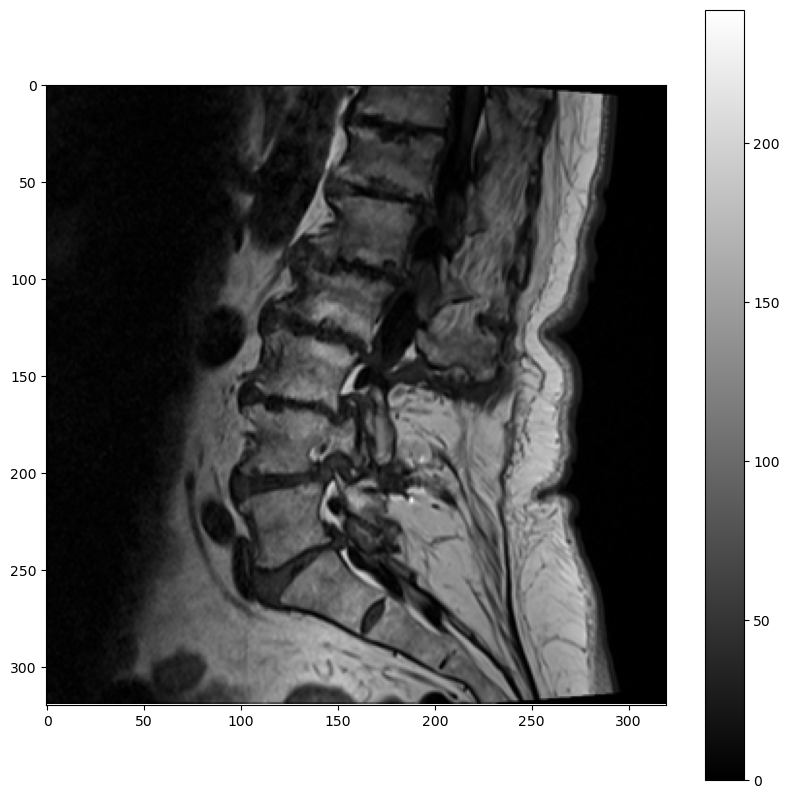

In [120]:
IMG_SIZE = (320, 320)
eps=1e-12

from utils import dicomToArray


plt.figure(figsize=(10,10))
_ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "test_images/44036939/2828203845/12.dcm"), IMG_SIZE), cmap="gray")
_ = plt.colorbar()



## Dataset

In [121]:
allFiles[0]

'D:/ML/RSNA2024\\test_images\\44036939\\2828203845\\1.dcm'

In [124]:
import albumentations as A
import glob
import re

imCount=10 #per seriesType


transforms = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(max_pixel_value=1.0)
])


def loadSampledData(studyId):
    imData = np.zeros((imCount*uniqueSeriesDescr.shape[0], *IMG_SIZE), dtype=np.uint8)
    for typeIdx, studyType in enumerate(uniqueSeriesDescr):
        try:
            seriesId = dfDescr.loc[(studyId, studyType)]["series_id"].to_numpy()
            seriesId = seriesId[0]
        except AttributeError:
            seriesId = dfDescr.loc[(studyId, studyType)]["series_id"]
        except KeyError:
            print(f"Not all relevant series types are present for {studyId=} ... skipping")
            continue

        allFilesInDir = glob.glob(os.path.join(DATA_PATH, f"test_images/{studyId}/{seriesId}/*.dcm"))
        #Sort by filename number
        try:
            allFilesInDir = sorted(allFilesInDir, key=lambda x:int(re.findall(r"\d+\.dcm", x)[0].replace(".dcm", "")))
        except Exception:
            print(f"Wrong filenames for sorting ({studyId=}, {seriesId=})")
        mult = len(allFilesInDir)/imCount

        if mult <= 1:
            for idx, _ in enumerate(allFilesInDir):
                instance = idx
                f = allFilesInDir[instance]
                imData[typeIdx*imCount + idx] = dicomToArray(f, IMG_SIZE)
        elif mult > 1 and mult < 2.5:
            diff = len(allFilesInDir) - imCount
            for idx in range(imCount):
                instance = diff//2+idx
                f = allFilesInDir[instance]
                imData[typeIdx*imCount + idx] = dicomToArray(f, IMG_SIZE)
        elif mult >= 2.5:
            stepsSize = np.floor(mult)-1
            stepCount = stepsSize*imCount
            diff = len(allFilesInDir) - stepCount
            for idx in range(imCount):
                instance = int(diff//2+idx*stepsSize)
                f = allFilesInDir[instance]
                imData[typeIdx*imCount + idx] = dicomToArray(f, IMG_SIZE)
        
    return imData



def generator():
    for studyId in allStudyIds:
        im = loadSampledData(studyId)
        im = im.astype(np.float32)
        for imIdx in range(imCount*uniqueSeriesDescr.shape[0]):
            im[imIdx] = im[imIdx]/255.0
            im[imIdx] = transforms(image=im[imIdx])["image"]
        im = torch.Tensor(im)
        yield im, studyId

loadSampledData(44036930).shape

Not all relevant series types are present for studyId=44036930 ... skipping
Not all relevant series types are present for studyId=44036930 ... skipping
Not all relevant series types are present for studyId=44036930 ... skipping


(30, 320, 320)

In [99]:
def plotAll(imArr):
    plt.figure(figsize=(9,10))
    for i in range(30):
        plt.subplot(6,5,i+1)
        plt.imshow(imArr[i,:,:])
        plt.axis("off")
        plt.tight_layout()


tensor(-2.1179) tensor(2.2489)
torch.Size([30, 320, 320])
44036939


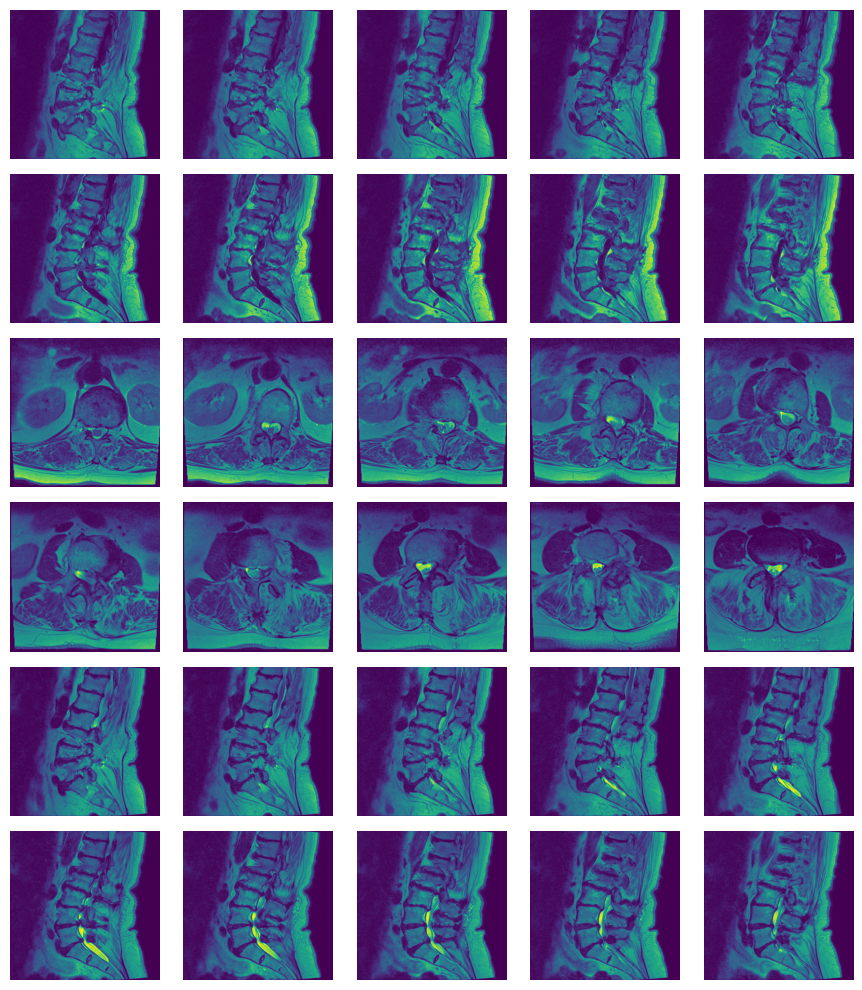

In [100]:
g = generator()
testInstance = next(g)

plotAll(testInstance[0].numpy())
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])

In [101]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(allStudyIds))

dataLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [102]:
for XData in dataLoader:
    print(f"Shape of X: {XData[0].shape} {XData[0].dtype}")
    print("Max and Min: ", torch.max(XData[0]), torch.min(XData[0]))
    print(XData[1])
    break

Shape of X: torch.Size([1, 30, 320, 320]) torch.float32
Max and Min:  tensor(2.2489) tensor(-2.1179)
tensor([44036939])


## Model

In [103]:
import torchinfo


use_amp = True


class Classifier(torch.nn.Module):
    def __init__(self, backbone):
        super(Classifier, self).__init__()
        self.basemodel = timm.create_model(backbone, pretrained=True, num_classes=len(allLabels)*len(labelMapping), in_chans=imCount*uniqueSeriesDescr.shape[0])
        self.name=f"DepthClassifier_{backbone}"

    def forward(self, x):
        x = self.basemodel(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        return x


model = Classifier("resnet18d")

# from torchview import draw_graph

# model_graph = draw_graph(model, input_size=(BATCH_SIZE,1,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)


with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
    print(torchinfo.summary(model, input_size=[BATCH_SIZE,imCount*uniqueSeriesDescr.shape[0],IMG_SIZE[0],IMG_SIZE[1]], depth=3))

INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/resnet18d.ra2_in1k)
INFO:timm.models._hub:[timm/resnet18d.ra2_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Converted input conv conv1.0 pretrained weights from 3 to 30 channel(s)
INFO:timm.models._builder:Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


Layer (type:depth-idx)                        Output Shape              Param #
Classifier                                    [32, 3, 25]               --
├─ResNet: 1-1                                 [32, 75]                  --
│    └─Sequential: 2-1                        [32, 64, 160, 160]        --
│    │    └─Conv2d: 3-1                       [32, 32, 160, 160]        8,640
│    │    └─BatchNorm2d: 3-2                  [32, 32, 160, 160]        64
│    │    └─ReLU: 3-3                         [32, 32, 160, 160]        --
│    │    └─Conv2d: 3-4                       [32, 32, 160, 160]        9,216
│    │    └─BatchNorm2d: 3-5                  [32, 32, 160, 160]        64
│    │    └─ReLU: 3-6                         [32, 32, 160, 160]        --
│    │    └─Conv2d: 3-7                       [32, 64, 160, 160]        18,432
│    └─BatchNorm2d: 2-2                       [32, 64, 160, 160]        128
│    └─ReLU: 2-3                              [32, 64, 160, 160]        --
│    └─Ma

In [104]:

checkpoint = torch.load(os.path.join(DATA_PATH, "models", "DepthClassifier_resnet18d_320_F1_0.430_CE_0.548_epoch_9.pt"), map_location=device)
print(model.load_state_dict(checkpoint['model_state_dict']))
model = model.to(device)


<All keys matched successfully>


In [105]:
results = {}

@torch.no_grad()
def validate(dataloader, model):
    model.eval()
    with torch.no_grad():
        for X, studyId in dataloader:
            X = X.to(device)
            pred = model(X)
            results[studyId.item()] = pred.detach().cpu().numpy()[0]


validate(dataLoader, model)
 

print("Done!")
# print(results)

Done!


In [110]:
from scipy.special import softmax

print(results[44036939].shape)
print(softmax(results[44036939], axis=0).shape)

(3, 25)
(3, 25)


In [111]:
entries = []

for studyId in results.keys():
    severeConds=[]
    probsAll = softmax(results[studyId], axis=0)
    for condIdx, cond in enumerate(allLabels):
        probs = probsAll[:, condIdx]
        entries.append([f"{studyId}_{cond}", *probs])
    print(f"{studyId} has severe cond: {severeConds}")
        

44036939 has severe cond: []


In [112]:
dfSubmission = pd.DataFrame(entries, columns=["row_id","normal_mild","moderate","severe"])
dfSubmission.head(20)

,row_id,normal_mild,moderate,severe
0,44036939_spinal_canal_stenosis_l1_l2,0.728944,0.203851,0.067205
1,44036939_spinal_canal_stenosis_l2_l3,0.335421,0.633659,0.030920
2,44036939_spinal_canal_stenosis_l3_l4,0.262603,0.678817,0.058579
3,44036939_spinal_canal_stenosis_l4_l5,0.188745,0.162652,0.648603
4,44036939_spinal_canal_stenosis_l5_s1,0.375869,0.091447,0.532684
5,44036939_left_neural_foraminal_narrowing_l1_l2,0.444560,0.554364,0.001077
6,44036939_left_neural_foraminal_narrowing_l2_l3,0.468819,0.513838,0.017342
7,44036939_left_neural_foraminal_narrowing_l3_l4,0.465373,0.331572,0.203056
8,44036939_left_neural_foraminal_narrowing_l4_l5,0.363185,0.510663,0.126152
9,44036939_left_neural_foraminal_narrowing_l5_s1,0.376648,0.543009,0.080343


In [109]:
dfSubmission.to_csv("submission.csv", index=False)